In [1]:
import os
from copy import deepcopy
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Imports from PyTorch.
import torch
from torch import nn
from torchvision import datasets, transforms
from torch import nn, Tensor
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torch import max as torch_max

import sys
# get the path of the current file
file = os.path.abspath('')
path = os.path.join(file, '../../src')
sys.path.append(path)
print(path)


# Imports from aihwkit.
from aihwkit.nn import AnalogConv2d, AnalogLinear, AnalogSequential
from aihwkit.optim import AnalogSGD
from aihwkit.nn.conversion import convert_to_analog
from aihwkit.simulator.configs import (
    SingleRPUConfig,
    FloatingPointRPUConfig,
    ConstantStepDevice,
    FloatingPointDevice,
)

from aihwkit.simulator.parameters import (
    WeightQuantizerParameter,
)
from aihwkit.simulator.parameters.enums import WeightQuantizerType

from aihwkit.simulator.rpu_base import cuda



# Check device
USE_CUDA = 0
if cuda.is_compiled():
    USE_CUDA = 1

if USE_CUDA:
    torch.cuda.set_device(0)
DEVICE = torch.device("cuda:0" if USE_CUDA else "cpu")
print("Device: ", DEVICE)


cur_dir = os.getcwd()
print("Current directory: ", cur_dir)


DUMP_DIR = os.path.join('/home/ecabiati/storage/inference_results')


/home/ecabiati/cellar/aihwkit/sandbox/cuda/../../src
Device:  cuda:0
Current directory:  /home/ecabiati/cellar/aihwkit/sandbox/cuda


## Definition of the RPU_CONFIGs with different calibrations
---
At this stage, the base RPU-configuration object is an ideal <code>FloatingPointRPUConfig</code> object, that is used to model a <i>floating-point device</i> (implements ideal devices forward/backward/update behavior).
This differs from the <code>InferenceRPUConfig</code>, that is used to model inference on real analog device (training is done in hardware-aware manner, thus using only the non-idealities of the forward-pass, but backward and update passes are ideal), or the <code>SingleRPUConfig</code>, that is the configuration for an analog (pulsed device) resistive processing unit ( update and backward passes are non-ideal). \
The only difference among the defined RPU_CONFIGs is the <code>quantization</code> field

In [2]:
LEVELS = [3, 5, 9, 17, 33]
RPU_CONFIG_BASE = FloatingPointRPUConfig() # Ideal device


# - - -  PERCENTILE  - - -
# We will also try different percentile values for each model.
RPU_CONFIG_PERCENTILE = deepcopy(RPU_CONFIG_BASE)
EPS = [0.03, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175]
RPU_CONFIG_PERCENTILE.quantization = WeightQuantizerParameter(
        eps= EPS[0],
        levels = LEVELS[0],
        method = "percentile"
    )
# - - -  ABS MAX  - - -
RPU_CONFIG_MAX = deepcopy(RPU_CONFIG_BASE)
RPU_CONFIG_MAX.quantization = WeightQuantizerParameter(
        levels = LEVELS[0],
        method = "max"
    )

# - - -  MSE - - -
RPU_CONFIG_MSE = deepcopy(RPU_CONFIG_BASE)
RPU_CONFIG_MSE.quantization = WeightQuantizerParameter(
        eps= EPS[0],
        levels = LEVELS[0],
        method = "mse"
    )

## Benchmarking the calibrations
---
We now compare the different approaches using 3 different models - LeNet5, VGG8, ResNet9s - on 3 different datasets respectively - MNIST, SVHN, CIFAR10. The models are pretrained using the <code>FloatingPointRPUConfig</code>, imported and the quantized using the different calibrations. Inference is then performed on the quantized models and the accuracy is recorded. The results are then compared. We also repeat the same measurements using the non idealities of the IRPS paper.

##  <b>1. LeNet5</b> :

In [6]:
# SEED = 1
# N_EPOCHS = 20
BATCH_SIZE = 128
# LEARNING_RATE = 0.01
N_CLASSES = 10
# Path to store MNIST dataset
PATH_DATASET = cur_dir + "/../data/mnist"

def load_images():
    """Load images for train from torchvision datasets."""

    transform = transforms.Compose([transforms.ToTensor()])
    train_set = datasets.MNIST(PATH_DATASET, download=True, train=True, transform=transform)
    val_set = datasets.MNIST(PATH_DATASET, download=True, train=False, transform=transform)
    train_data = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data


def create_analog_network(RPU_CONFIG):
    """Return a LeNet5 inspired analog model."""
    channel = [16, 32, 512, 128]
    model = AnalogSequential(
        AnalogConv2d(
            in_channels=1, out_channels=channel[0], kernel_size=5, stride=1, rpu_config=RPU_CONFIG
        ),
        nn.Tanh(),
        nn.MaxPool2d(kernel_size=2),
        AnalogConv2d(
            in_channels=channel[0],
            out_channels=channel[1],
            kernel_size=5,
            stride=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.Tanh(),
        nn.MaxPool2d(kernel_size=2),
        nn.Tanh(),
        nn.Flatten(),
        AnalogLinear(in_features=channel[2], out_features=channel[3], rpu_config=RPU_CONFIG),
        nn.Tanh(),
        AnalogLinear(in_features=channel[3], out_features=N_CLASSES, rpu_config=RPU_CONFIG),
        nn.LogSoftmax(dim=1),
    )

    return model

def test_evaluation(validation_data, model, criterion):
    """Test trained network.

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float:  model, loss, error, and accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy


In [4]:
_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()

# Standard (unquantized) model
rpu_config = RPU_CONFIG_BASE
RESULTS_NON_QUANTIZED = cur_dir + "/lenet5_results"


state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "LeNet5.th"), map_location=DEVICE)
non_quantized_model = create_analog_network(rpu_config).to(DEVICE)
non_quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model: {accuracy_non_quantized:.2f}%")

# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS)))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels

        model = create_analog_network(rpu_config).to(DEVICE)
        model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
        model.eval()
        quantized_model = convert_to_analog(model, rpu_config)

        _, _, _, accuracies_percentile[i, j] = test_evaluation(validation_data, quantized_model, criterion)
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j]:.2f}%")
        del model
        del quantized_model

# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MAX)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    model.eval()
    quantized_model = convert_to_analog(model, rpu_config)

    _, _, _, accuracies_max[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j]:.2f}%")
    del model
    del quantized_model

# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MSE)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    model.eval()
    quantized_model = convert_to_analog(model, rpu_config)

    _, _, _, accuracies_mse[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j]:.2f}%")
    del model
    del quantized_model


# Save the results
results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "max": accuracies_max,
    "mse": accuracies_mse,
}

torch.save(results, os.path.join(DUMP_DIR, "results_lenet5.th"))

Accuracy of the non-quantized model: 97.59%
 = = = = = = = =  Percentile calibration  = = = = = = = = 
Accuracy of the percentile model with eps=0.030 and levels=3: 96.58%
Accuracy of the percentile model with eps=0.030 and levels=5: 97.48%
Accuracy of the percentile model with eps=0.030 and levels=9: 97.53%
Accuracy of the percentile model with eps=0.030 and levels=17: 97.50%
Accuracy of the percentile model with eps=0.030 and levels=33: 97.57%
Accuracy of the percentile model with eps=0.050 and levels=3: 97.05%
Accuracy of the percentile model with eps=0.050 and levels=5: 97.59%
Accuracy of the percentile model with eps=0.050 and levels=9: 97.50%
Accuracy of the percentile model with eps=0.050 and levels=17: 97.50%
Accuracy of the percentile model with eps=0.050 and levels=33: 97.54%
Accuracy of the percentile model with eps=0.075 and levels=3: 97.04%
Accuracy of the percentile model with eps=0.075 and levels=5: 97.56%
Accuracy of the percentile model with eps=0.075 and levels=9: 97.

In [7]:
# Load the results
results = torch.load(os.path.join(DUMP_DIR, "results_lenet5.th"))

# Find the (mean) best percentile eps values considering all the levels
mean_accuracy_percentile = results["percentile"].mean(axis=1)
#print(f"Mean accuracies: {mean_accuracy_percentile}")
best_eps_index = mean_accuracy_percentile.argmax()
best_eps = EPS[best_eps_index]
print(f"Best eps: {best_eps}")

Best eps: 0.05


In [3]:
def heatmap(data, row_labels, col_labels, ax = None,
            cbar_kw = {}, cbarlabel = "", title = "", **kwargs):

    if not ax:
      ax = plt.gca()

    im = ax.imshow(data, **kwargs)
    ax.set_title(title, fontdict={"fontsize": 14}, y = -0.075)

    cbar = ax.figure.colorbar(im, ax = ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation = -90, va = "bottom",fontdict = {"fontsize": 12})

    ax.set_xticks(np.arange(data.shape[1]), labels = col_labels)
    ax.set_yticks(np.arange(data.shape[0]), labels = row_labels)

    ax.tick_params(top = True, bottom = False,
                   labeltop = True, labelbottom = False)

    plt.setp(ax.get_xticklabels(), rotation = -30, ha = "right",
             rotation_mode = "anchor")

    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1] + 1) - 0.5, minor = True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - 0.5, minor = True)
    ax.grid(which = "minor", color = "k", linestyle = '-', linewidth = 4, zorder = 3)
    y_ticks = np.arange(data.shape[0] + 1) - 0.5
    x_ticks = np.arange(data.shape[1] + 1) - 0.5
    for y in y_ticks:
        ax.axhline(y=y, color='w', linewidth=3, zorder=3)
    for x in x_ticks:
        ax.axvline(x=x, color='w', linewidth=3, zorder=3)
    ax.tick_params(which =  "minor", bottom = False, left = False)

    return im, cbar


def annotate_heatmap(im, data = None, valfmt="{x:.2f}",
                     textcolors = ("black", "white"),
                     threshold = None, **textkw):

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    kw = dict(horizontalalignment = "center",
              verticalalignment = "center")
    kw.update(textkw)

    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) < threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

Text(0.5, 1.0, 'Comparison of calibration methods')

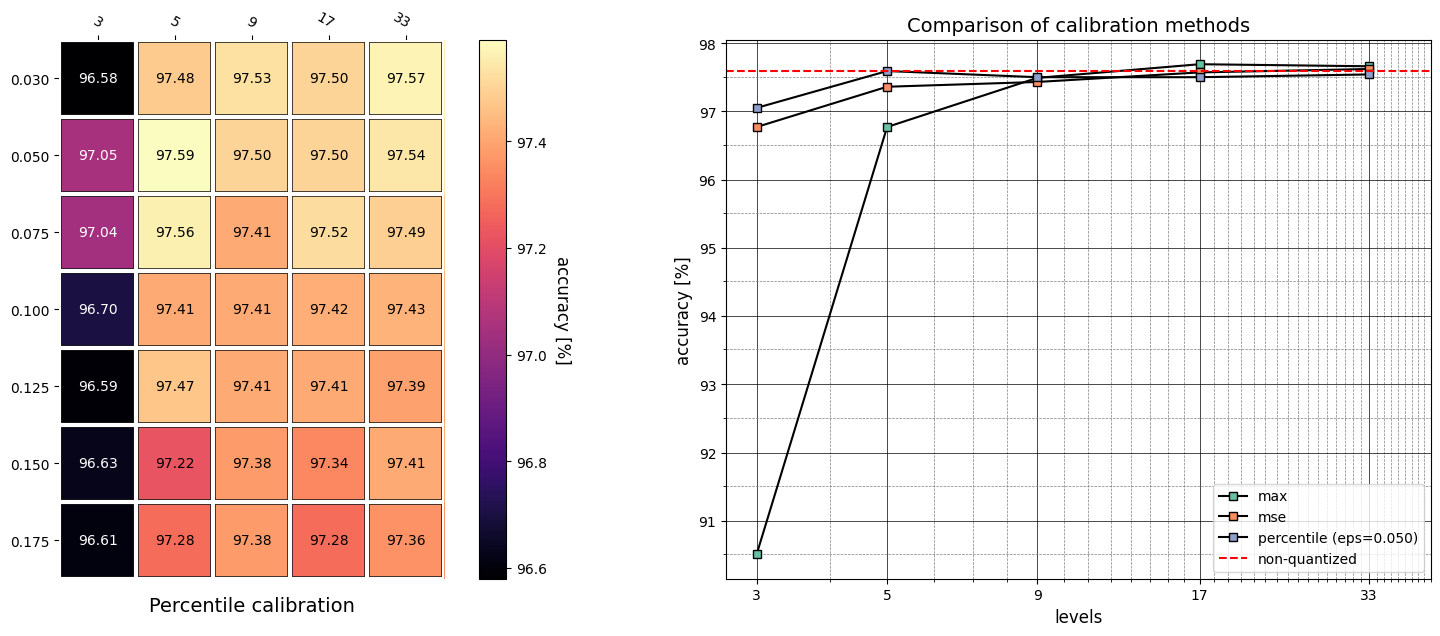

In [10]:


# =========================================================================================

fig, axs = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1, 1]})

xlabs = [f"{eps:.3f}" for eps in EPS]
ylabs = [str(levels) for levels in LEVELS]

im, cbar = heatmap( results["percentile"], row_labels = xlabs, col_labels = ylabs,
                   ax = axs[0], cmap = "magma", aspect = "equal", cbarlabel = "accuracy [%]", title = "Percentile calibration")
texts = annotate_heatmap(im, valfmt = "{x:.2f}")

# The second plot shows the comparison between the different calibration methods
data = np.array([ results["max"], results["mse"], results["percentile"][best_eps_index, :]])
x = LEVELS


colors = matplotlib.colormaps["Set2"].colors
axs[1].plot(x, data[0], label = "max", marker = "s", markerfacecolor = colors[0], color = "k")
axs[1].plot(x, data[1], label = "mse", marker = "s", markerfacecolor = colors[1], color = "k")
axs[1].plot(x, data[2], label = f"percentile (eps={best_eps:.3f})", marker = "s", markerfacecolor = colors[2], color = "k")

axs[1].set_xscale("log", base = 2)
axs[1].set_xticks(x)
axs[1].set_xticklabels([str(levels) for levels in x])
axs[1].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
axs[1].xaxis.set_minor_formatter(plt.NullFormatter())
axs[1].set_yticks(np.arange(np.min(data), np.max(data), 1.0), minor = True)
axs[1].axhline(y = results["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 1.5)


axs[1].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
axs[1].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs[1].legend()
axs[1].set_xlabel("levels", fontdict = {"fontsize": 12})
axs[1].set_ylabel("accuracy [%]", fontdict = {"fontsize": 12})
axs[1].set_title("Comparison of calibration methods", fontdict = {"fontsize": 14})


## <b>2. VGG8</b> :

In [23]:
# SEED = 1
# N_EPOCHS = 20
BATCH_SIZE = 128
# LEARNING_RATE = 0.1
N_CLASSES = 10
PATH_DATASET = cur_dir + "/../data/svhn"

# RPU_CONFIG.runtime.offload_gradient = True
# RPU_CONFIG.runtime.offload_input = True


def load_images():
    """Load images for train from torchvision datasets."""
    mean = Tensor([0.4377, 0.4438, 0.4728])
    std = Tensor([0.1980, 0.2010, 0.1970])

    print(f"Normalization data: ({mean},{std})")

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
    train_set = datasets.SVHN(PATH_DATASET, download=True, split="train", transform=transform)
    val_set = datasets.SVHN(PATH_DATASET, download=True, split="test", transform=transform)
    train_data = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data


def create_analog_network(RPU_CONFIG):
    """Create a Vgg8 inspired analog model.

    Returns:
       nn.Module: VGG8 model
    """
    channel_base = 48
    channel = [channel_base, 2 * channel_base, 3 * channel_base]
    fc_size = 8 * channel_base
    model = AnalogSequential(
        AnalogConv2d(in_channels=3, out_channels=channel[0], kernel_size=3, stride=1, padding=1, rpu_config=RPU_CONFIG),
        nn.ReLU(),
        AnalogConv2d(
            in_channels=channel[0],
            out_channels=channel[0],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.BatchNorm2d(channel[0]),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1),
        AnalogConv2d(
            in_channels=channel[0],
            out_channels=channel[1],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.ReLU(),
        AnalogConv2d(
            in_channels=channel[1],
            out_channels=channel[1],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.BatchNorm2d(channel[1]),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1),
        AnalogConv2d(
            in_channels=channel[1],
            out_channels=channel[2],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.ReLU(),
        AnalogConv2d(
            in_channels=channel[2],
            out_channels=channel[2],
            kernel_size=3,
            stride=1,
            padding=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.BatchNorm2d(channel[2]),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1),
        nn.Flatten(),
        AnalogLinear(in_features=16 * channel[2], out_features=fc_size, rpu_config=RPU_CONFIG),
        nn.ReLU(),
        AnalogLinear(in_features=fc_size, out_features=N_CLASSES, rpu_config=RPU_CONFIG),
        nn.LogSoftmax(dim=1),
    )
    return model

def test_evaluation(validation_data, model, criterion):
    """Test trained network

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float: model, test epoch loss, test error, and test accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch_max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy

In [24]:
_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()
rpu_config = FloatingPointRPUConfig()

# Standard model
RESULTS_NON_QUANTIZED = cur_dir + "/vgg8_results"
state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "vgg8.th"), map_location=DEVICE)
non_quantized_model = create_analog_network(rpu_config).to(DEVICE)
non_quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model: {accuracy_non_quantized:.2f}%")

# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS)))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels

        model = create_analog_network(rpu_config).to(DEVICE)
        model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
        quantized_model = convert_to_analog(model, rpu_config)
        quantized_model.eval()

        _, _, _, accuracies_percentile[i, j] = test_evaluation(validation_data, quantized_model, criterion)
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j]:.2f}%")
        del model
        del quantized_model

# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MAX)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_max[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j]:.2f}%")
    del model
    del quantized_model

# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MSE)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_mse[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j]:.2f}%")
    del model
    del quantized_model


# Save the results
results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "max": accuracies_max,
    "mse": accuracies_mse,
}

torch.save(results, os.path.join(DUMP_DIR, "results_vgg8.th"))



Normalization data: (tensor([0.4377, 0.4438, 0.4728]),tensor([0.1980, 0.2010, 0.1970]))
Using downloaded and verified file: /home/ecabiati/cellar/aihwkit/sandbox/cuda/../data/svhn/train_32x32.mat
Using downloaded and verified file: /home/ecabiati/cellar/aihwkit/sandbox/cuda/../data/svhn/test_32x32.mat
Accuracy of the non-quantized model: 94.89%
 = = = = = = = =  Percentile calibration  = = = = = = = = 
Accuracy of the percentile model with eps=0.030 and levels=3: 78.97%
Accuracy of the percentile model with eps=0.030 and levels=5: 89.19%
Accuracy of the percentile model with eps=0.030 and levels=9: 93.04%
Accuracy of the percentile model with eps=0.030 and levels=17: 92.88%
Accuracy of the percentile model with eps=0.030 and levels=33: 93.29%
Accuracy of the percentile model with eps=0.050 and levels=3: 83.67%
Accuracy of the percentile model with eps=0.050 and levels=5: 90.78%
Accuracy of the percentile model with eps=0.050 and levels=9: 92.07%
Accuracy of the percentile model with ep

In [11]:
# Load the results
results = torch.load(os.path.join(DUMP_DIR, "results_vgg8.th"))

# Find the (mean) best percentile eps values considering all the levels
mean_accuracy_percentile = results["percentile"].mean(axis=1)
#print(f"Mean accuracies: {mean_accuracy_percentile}")
best_eps_index = mean_accuracy_percentile.argmax()
best_eps = EPS[best_eps_index]
print(f"Best eps: {best_eps}")

Best eps: 0.05


Text(0.5, 1.0, 'Comparison of calibration methods')

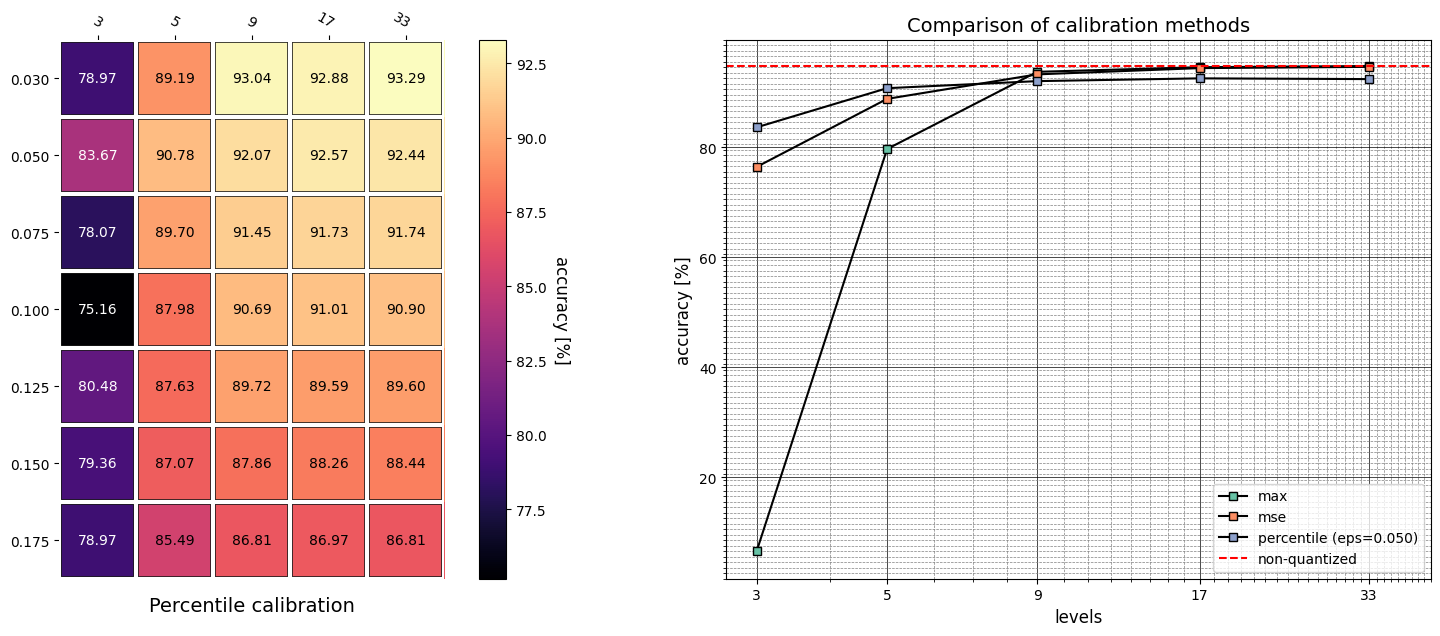

In [12]:
# =========================================================================================

fig, axs = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1, 1]})

xlabs = [f"{eps:.3f}" for eps in EPS]
ylabs = [str(levels) for levels in LEVELS]

im, cbar = heatmap( results["percentile"], row_labels = xlabs, col_labels = ylabs,
                   ax = axs[0], cmap = "magma", aspect = "equal", cbarlabel = "accuracy [%]", title = "Percentile calibration")
texts = annotate_heatmap(im, valfmt = "{x:.2f}")

# The second plot shows the comparison between the different calibration methods
data = np.array([ results["max"], results["mse"], results["percentile"][best_eps_index, :]])
x = LEVELS


colors = matplotlib.colormaps["Set2"].colors
axs[1].plot(x, data[0], label = "max", marker = "s", markerfacecolor = colors[0], color = "k")
axs[1].plot(x, data[1], label = "mse", marker = "s", markerfacecolor = colors[1], color = "k")
axs[1].plot(x, data[2], label = f"percentile (eps={best_eps:.3f})", marker = "s", markerfacecolor = colors[2], color = "k")

axs[1].set_xscale("log", base = 2)
axs[1].set_xticks(x)
axs[1].set_xticklabels([str(levels) for levels in x])
axs[1].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
axs[1].xaxis.set_minor_formatter(plt.NullFormatter())
axs[1].set_yticks(np.arange(np.min(data) -5, np.max(data) +5, 1.0), minor = True)
axs[1].axhline(y = results["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 1.5)


axs[1].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
axs[1].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs[1].legend()
axs[1].set_xlabel("levels", fontdict = {"fontsize": 12})
axs[1].set_ylabel("accuracy [%]", fontdict = {"fontsize": 12})
axs[1].set_title("Comparison of calibration methods", fontdict = {"fontsize": 14})

## <b>3. ResNet9s</b> :

In [4]:
# SEED = 1
# N_EPOCHS = 40
BATCH_SIZE = 64
# LEARNING_RATE = 0.01
N_CLASSES = 10
PATH_DATASET = cur_dir + "/../data/cifar10"

import torchvision

class TorchCutout(object):
    def __init__(self, length, fill=(0.0, 0.0, 0.0)):
        self.length = length
        self.fill = torch.tensor(fill).reshape(shape=(3, 1, 1))

    def __call__(self, img):
        h = img.size(1)
        w = img.size(2)
        y = np.random.randint(h)
        x = np.random.randint(w)
        y1 = np.clip(y - self.length // 2, 0, h)
        y2 = np.clip(y + self.length // 2, 0, h)
        x1 = np.clip(x - self.length // 2, 0, w)
        x2 = np.clip(x + self.length // 2, 0, w)
        img[:, y1:y2, x1:x2] = self.fill
        return img

def load_images():
    transform_train = transforms.Compose(
        [
            torchvision.transforms.RandomCrop(32, padding=4),
            torchvision.transforms.RandomHorizontalFlip(),
            transforms.ToTensor(), 
            transforms.Normalize(
                (0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010)
            ),
            TorchCutout(length=8)
            ])
    
    transform_test = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
            ),
        ]
    )

    train_set = datasets.CIFAR10(PATH_DATASET, train=True, download=True, transform=transform_train)
    val_set = datasets.CIFAR10(PATH_DATASET, train=False, download=True, transform=transform_test)
    train_data = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data

class LambdaLayer(torch.nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(torch.nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, option="A", RPU_CONFIG=None):
        super(BasicBlock, self).__init__()
        self.conv1 = AnalogConv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn1 = torch.nn.BatchNorm2d(planes)
        self.conv2 = AnalogConv2d(
            planes, planes, kernel_size=3, stride=1, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn2 = torch.nn.BatchNorm2d(planes)

        self.shortcut = AnalogSequential()
        if stride != 1 or in_planes != planes:
            if option == "A":
                """
                For CIFAR10 ResNet paper uses option A.
                """
                self.shortcut = LambdaLayer(
                    lambda x: F.pad(
                        x[:, :, ::2, ::2],
                        (0, 0, 0, 0, planes // 4, planes // 4),
                        "constant",
                        0,
                    )
                )
            elif option == "B":
                self.shortcut = AnalogSequential(
                    AnalogConv2d(
                        in_planes,
                        self.expansion * planes,
                        kernel_size=1,
                        stride=stride,
                        bias=False,
                        rpu_config=RPU_CONFIG,
                    ),
                    torch.nn.BatchNorm2d(self.expansion * planes),
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


def Resnet9(channels, RPU_CONFIG, first_layer_quantization = True):
    """
    From https://github.com/matthias-wright/cifar10-resnet/
    """

    # resnet9 [56,112,224,224]
    # resnet9s [28,28,28,56]

    FIRST_LAYER_RPU_CONFIG = deepcopy(RPU_CONFIG)
    if first_layer_quantization == False:
        FIRST_LAYER_RPU_CONFIG.quantization = WeightQuantizerParameter(
            quantizer_type=WeightQuantizerType.NONE
        )

        print("No quantization for the first layer has been requested.")
        print("First layer RPU_CONFIG: ", FIRST_LAYER_RPU_CONFIG.quantization)
        print("Original RPU_CONFIG quantization parameter: ", RPU_CONFIG.quantization)


    model = AnalogSequential(
        # prep
        AnalogConv2d(
            in_channels=3,
            out_channels=channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=FIRST_LAYER_RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[0], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        # Layer 1
        AnalogConv2d(
            in_channels=channels[0],
            out_channels=channels[1],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[1], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[1], planes=channels[1], stride=1, RPU_CONFIG=RPU_CONFIG),
        # Layer 2
        AnalogConv2d(
            in_channels=channels[1],
            out_channels=channels[2],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[2], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        # Layer 3
        AnalogConv2d(
            in_channels=channels[2],
            out_channels=channels[3],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[3], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[3], planes=channels[3], stride=1, RPU_CONFIG=RPU_CONFIG),
        torch.nn.MaxPool2d(kernel_size=4, stride=4),
        torch.nn.Flatten(),
        AnalogLinear(in_features=channels[3], out_features=10, bias=True, rpu_config=RPU_CONFIG)
    )

    return model



def create_analog_network(RPU_CONFIG, first_layer_quantization = True):
    return Resnet9(channels=[28,28,28,56], RPU_CONFIG=RPU_CONFIG, first_layer_quantization = first_layer_quantization)



def test_evaluation(validation_data, model, criterion):
    """Test trained network

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float: model, test epoch loss, test error, and test accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch_max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy


In [5]:
#
# =========================================================================================
#                          EVALUATION OF PERSONALLY TRAINED RESNET9
# =========================================================================================
#
_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()

rpu_config = FloatingPointRPUConfig()

# Stardard model trained on FloatingPointRPUConfig
RESULTS_NON_QUANTIZED = cur_dir + "/resnet9_results"
state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9.th"), map_location=DEVICE)
non_quantized_model = create_analog_network(rpu_config).to(DEVICE)
non_quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model (personally trained): {accuracy_non_quantized:.2f}%")

del non_quantized_model
torch.cuda.empty_cache()
# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS)))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels

        model = create_analog_network(rpu_config).to(DEVICE)
        model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
        quantized_model = convert_to_analog(model, rpu_config)
        quantized_model.eval()

        _, _, _, accuracies_percentile[i, j] = test_evaluation(validation_data, quantized_model, criterion)
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j]:.2f}%")
        del model
        del quantized_model
        torch.cuda.empty_cache()
        

# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MAX)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_max[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j]:.2f}%")
    del model
    del quantized_model
    torch.cuda.empty_cache()

# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MSE)
    rpu_config.quantization.levels = levels

    model = create_analog_network(rpu_config).to(DEVICE)
    model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_mse[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j]:.2f}%")
    del model
    del quantized_model
    torch.cuda.empty_cache()


# Save the results
results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "max": accuracies_max,
    "mse": accuracies_mse,
}

torch.save(results, os.path.join(DUMP_DIR, "results_resnet9s_own.th"))


Files already downloaded and verified
Files already downloaded and verified
Accuracy of the non-quantized model (personally trained): 83.80%
 = = = = = = = =  Percentile calibration  = = = = = = = = 
Accuracy of the percentile model with eps=0.030 and levels=3: 17.89%
Accuracy of the percentile model with eps=0.030 and levels=5: 29.50%
Accuracy of the percentile model with eps=0.030 and levels=9: 69.69%
Accuracy of the percentile model with eps=0.030 and levels=17: 74.73%
Accuracy of the percentile model with eps=0.030 and levels=33: 73.29%
Accuracy of the percentile model with eps=0.050 and levels=3: 25.37%
Accuracy of the percentile model with eps=0.050 and levels=5: 17.85%
Accuracy of the percentile model with eps=0.050 and levels=9: 57.49%
Accuracy of the percentile model with eps=0.050 and levels=17: 67.22%
Accuracy of the percentile model with eps=0.050 and levels=33: 67.46%
Accuracy of the percentile model with eps=0.075 and levels=3: 16.62%
Accuracy of the percentile model with

In [6]:

#
# =========================================================================================
#                          EVALUATION OF AIHWKIT TRAINED RESNET9
# =========================================================================================
#
from shared import resnet9s, CustomDefinedPreset, IdealPreset
from resnet import get_test_loader
from aihwkit.inference.calibration import (
    calibrate_input_ranges,
    InputRangeCalibrationType,
)

TIMES = 10

# Sampler class to use for input calibration
class Sampler:
    """Example of a sampler used for calibration."""

    def __init__(self, loader, device):
        self.device = device
        self.loader = iter(loader)
        self.idx = 0

    def __iter__(self):
        return self

    def __next__(self):
        x, _ = next(self.loader)
        self.idx += 1
        if self.idx > 100:
            raise StopIteration

        return ([x.to(self.device)], {})

# Load datasets.
validation_data = get_test_loader()
criterion = nn.CrossEntropyLoss()


# rpu_config = FloatingPointRPUConfig()
rpu_config = CustomDefinedPreset()

# aihwkit model, trained on StandardHWATrainingPreset
RESULTS_NON_QUANTIZED = cur_dir + "/../resnet"
state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9s.th"), map_location=DEVICE)

accuracy_non_quantized = np.zeros(TIMES)
for t in range(TIMES):
    dataloader = Sampler(validation_data, DEVICE)
    non_quantized_model = resnet9s().to(DEVICE)
    non_quantized_model.load_state_dict(state_dict["model_state_dict"], strict=True)
    non_quantized_model = convert_to_analog(non_quantized_model, rpu_config)
    non_quantized_model.eval()
    calibrate_input_ranges(
                        model=non_quantized_model,
                        calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                        dataloader=dataloader,
                        )
    
    del dataloader

    _, _, _, accuracy_non_quantized[t] = test_evaluation(validation_data, non_quantized_model, criterion)
    del non_quantized_model

print(f"Accuracy of the non-quantized model (aihwkit trained): {accuracy_non_quantized.mean():.2f}%")
accuracy_non_quantized = accuracy_non_quantized.mean()


# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS), TIMES))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = CustomDefinedPreset()
        rpu_config.quantization = RPU_CONFIG_PERCENTILE.quantization
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels
        for t in range(TIMES):
            dataloader = Sampler(validation_data, DEVICE)

            model = resnet9s().to(DEVICE)
            model.load_state_dict(state_dict["model_state_dict"], strict=True)
            quantized_model = convert_to_analog(model, rpu_config)
            calibrate_input_ranges(
                        model=quantized_model,
                        calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                        dataloader=dataloader,
                        )
            quantized_model.eval()
            
            _, _, _, accuracies_percentile[i, j, t] = test_evaluation(validation_data, quantized_model, criterion)
            
            del model
            del quantized_model
            del dataloader
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j, :].mean():.2f}%")
accuracies_percentile_std = accuracies_percentile.std(axis=2)
accuracies_percentile = accuracies_percentile.mean(axis=2)


# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros((len(LEVELS), TIMES))
for j, levels in enumerate(LEVELS):

    rpu_config = CustomDefinedPreset()
    rpu_config.quantization = RPU_CONFIG_MAX.quantization
    rpu_config.quantization.levels = levels

    for t in range(TIMES):
        dataloader = Sampler(validation_data, DEVICE)

        model = resnet9s().to(DEVICE)
        model.load_state_dict(state_dict["model_state_dict"], strict=True)
        quantized_model = convert_to_analog(model, rpu_config)
        calibrate_input_ranges(
                    model=quantized_model,
                    calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                    dataloader=dataloader,
                    )
        quantized_model.eval()

        _, _, _, accuracies_max[j, t] = test_evaluation(validation_data, quantized_model, criterion)
        del model
        del quantized_model
        del dataloader

    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j, :].mean():.2f}%")
accuracies_max_std = accuracies_max.std(axis=1)
accuracies_max = accuracies_max.mean(axis=1)


# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros((len(LEVELS), TIMES))
for j, levels in enumerate(LEVELS):
    rpu_config = CustomDefinedPreset()
    rpu_config.quantization = RPU_CONFIG_MSE.quantization
    rpu_config.quantization.levels = levels
    
    for t in range(TIMES):
        dataloader = Sampler(validation_data, DEVICE)

        model = resnet9s().to(DEVICE)
        model.load_state_dict(state_dict["model_state_dict"], strict=True)
        quantized_model = convert_to_analog(model, rpu_config)
        calibrate_input_ranges(
                    model=quantized_model,
                    calibration_type=InputRangeCalibrationType.CACHE_QUANTILE,
                    dataloader=dataloader,
                    )
        quantized_model.eval()

        _, _, _, accuracies_mse[j, t] = test_evaluation(validation_data, quantized_model, criterion)
        del model
        del quantized_model
        del dataloader
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j, :].mean():.2f}%")
accuracies_mse_std = accuracies_mse.std(axis=1)
accuracies_mse = accuracies_mse.mean(axis=1)



results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "percentile_std": accuracies_percentile_std,
    "max": accuracies_max,
    "max_std": accuracies_max_std,
    "mse": accuracies_mse,
    "mse_std": accuracies_mse_std,
}

torch.save(results, os.path.join(DUMP_DIR, "results_resnet9s_aihwkit.th"))

Files already downloaded and verified








































































































































































































































































































































































































































































































































Accuracy of the non-quantized model (aihwkit trained): 79.97%
 = = = = = = = =  Percentile calibration  = = = = = = = = 



































































































































































































































































































































In [8]:
# results = {
#     "non_quantized": accuracy_non_quantized,
#     "percentile": accuracies_percentile,
# }

# torch.save(results, os.path.join(DUMP_DIR, "percentile_resnet9s_aihwkit.th"))

In [7]:
# Load the results
results1 = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_own.th"))
results2 = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_aihwkit.th"))

# Find the (mean) best percentile eps values considering all the levels
mean_accuracy_percentile1 = results1["percentile"].mean(axis=1)
mean_accuracy_percentile2 = results2["percentile"].mean(axis=1)
#print(f"Mean accuracies: {mean_accuracy_percentile}")
best_eps_index1 = mean_accuracy_percentile1.argmax()
best_eps_index2 = mean_accuracy_percentile2.argmax()
best_eps1 = EPS[best_eps_index1]
best_eps2 = EPS[best_eps_index2]
print(f"Best eps (own resnet9s): {best_eps1}")
print(f"Best eps (aihwkit resnet9s): {best_eps2}")

Best eps (own resnet9s): 0.03
Best eps (aihwkit resnet9s): 0.075


Text(0.5, 1.0, 'Comparison of calibration methods (aihwkit trained)')

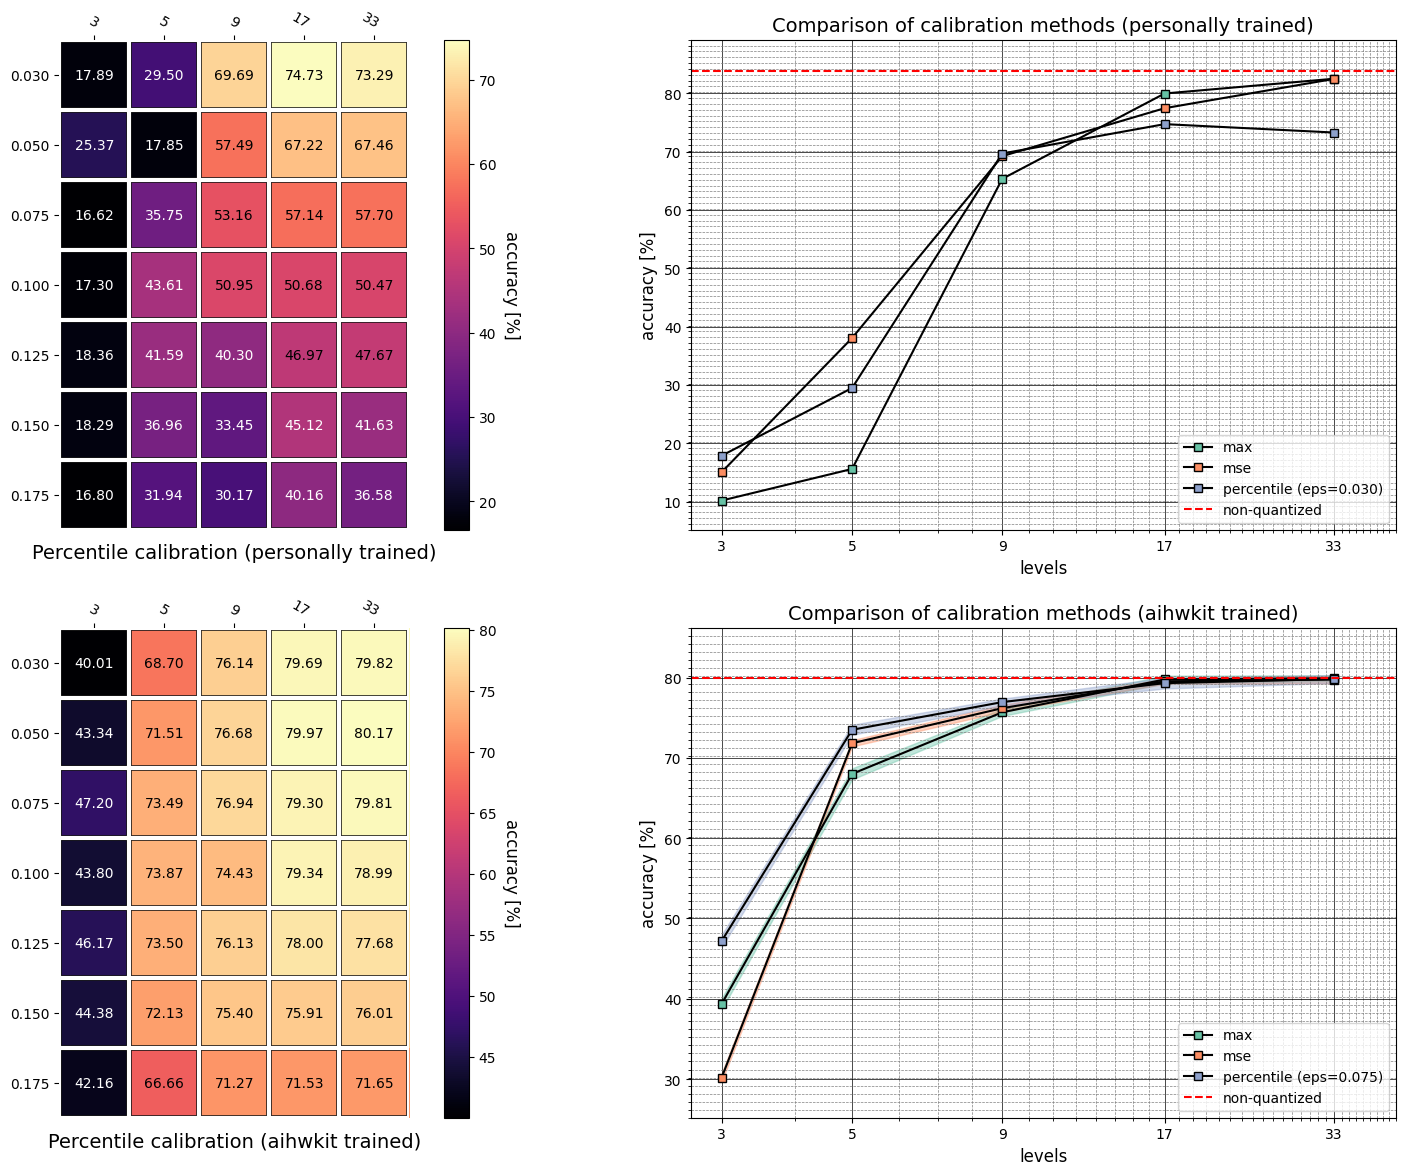

In [8]:
# =========================================================================================

fig, axs = plt.subplots(2, 2, figsize=(20, 14), gridspec_kw={"width_ratios": [1, 1]})

xlabs = [f"{eps:.3f}" for eps in EPS]
ylabs = [str(levels) for levels in LEVELS]

im, cbar = heatmap( results1["percentile"], row_labels = xlabs, col_labels = ylabs,
                   ax = axs[0,0], cmap = "magma", aspect = "equal", cbarlabel = "accuracy [%]", title = "Percentile calibration (personally trained)")
texts = annotate_heatmap(im, valfmt = "{x:.2f}")

im, cbar = heatmap( results2["percentile"], row_labels = xlabs, col_labels = ylabs,
                     ax = axs[1,0], cmap = "magma", aspect = "equal", cbarlabel = "accuracy [%]", title = "Percentile calibration (aihwkit trained)")
texts = annotate_heatmap(im, valfmt = "{x:.2f}")

# The second plot shows the comparison between the different calibration methods
data1 = np.array([ results1["max"], results1["mse"], results1["percentile"][best_eps_index1, :]])
data2 = np.array([ results2["max"], results2["mse"], results2["percentile"][best_eps_index2, :]])
x = LEVELS


colors = matplotlib.colormaps["Set2"].colors
axs[0,1].plot(x, data1[0], label = "max", marker = "s", markerfacecolor = colors[0], color = "k")
axs[0,1].plot(x, data1[1], label = "mse", marker = "s", markerfacecolor = colors[1], color = "k")
axs[0,1].plot(x, data1[2], label = f"percentile (eps={best_eps1:.3f})", marker = "s", markerfacecolor = colors[2], color = "k")
axs[0,1].set_xscale("log", base = 2)
axs[0,1].set_xticks(x)
axs[0,1].set_xticklabels([str(levels) for levels in x])
axs[0,1].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
axs[0,1].xaxis.set_minor_formatter(plt.NullFormatter())
axs[0,1].set_yticks(np.arange(np.min(data1)-5, np.max(data1) +7 , 1.0), minor = True)
axs[0,1].axhline(y = results1["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 1.5)
axs[0,1].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
axs[0,1].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs[0,1].legend()
axs[0,1].set_xlabel("levels", fontdict = {"fontsize": 12})
axs[0,1].set_ylabel("accuracy [%]", fontdict = {"fontsize": 12})
axs[0,1].set_title("Comparison of calibration methods (personally trained)", fontdict = {"fontsize": 14})


axs[1,1].plot(x, data2[0], label = "max", marker = "s", markerfacecolor = colors[0], color = "k")
axs[1,1].fill_between(x, data2[0] - results2["max_std"], data2[0] + results2["max_std"], alpha = 0.4, color = colors[0])
axs[1,1].plot(x, data2[1], label = "mse", marker = "s", markerfacecolor = colors[1], color = "k")
axs[1,1].fill_between(x, data2[1] - results2["mse_std"], data2[1] + results2["mse_std"], alpha = 0.4, color = colors[1])
axs[1,1].plot(x, data2[2], label = f"percentile (eps={best_eps2:.3f})", marker = "s", markerfacecolor = colors[2], color = "k")
axs[1,1].fill_between(x, data2[2] - results2["percentile_std"][best_eps_index2], data2[2] + results2["percentile_std"][best_eps_index2], alpha = 0.4, color = colors[2])
axs[1,1].set_xscale("log", base = 2)
axs[1,1].set_xticks(x)
axs[1,1].set_xticklabels([str(levels) for levels in x])
axs[1,1].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
axs[1,1].xaxis.set_minor_formatter(plt.NullFormatter())
axs[1,1].set_yticks(np.arange(np.min(data2)-5, np.max(data2)+7, 1.0), minor = True)
axs[1,1].axhline(y = results2["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 1.5)
axs[1,1].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
axs[1,1].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs[1,1].legend()
axs[1,1].set_xlabel("levels", fontdict = {"fontsize": 12})
axs[1,1].set_ylabel("accuracy [%]", fontdict = {"fontsize": 12})
axs[1,1].set_title("Comparison of calibration methods (aihwkit trained)", fontdict = {"fontsize": 14})



### Pytorch Resnet9s model
In this section, a resnet9s model, same as the other ones, is trained in pure pytorch, then loaded and quantization is performed using the different calibrations. We then compare the results with the other models previously quantized.

In [9]:
# the model is already trained and saved in the "resnet9_base_results" folder
PYTORCH_MODEL_PATH = cur_dir + "/resnet9_base_results/resnet9_base.th"

from shared import resnet9s

_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()
model = resnet9s().to(DEVICE)
model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
model.eval()
accuracy_pytorch = test_evaluation(validation_data, model, criterion)[3]
print(accuracy_pytorch)

Files already downloaded and verified
Files already downloaded and verified
86.75


In [10]:


#
# =========================================================================================
#                          EVALUATION OF PYTORCH TRAINED RESNET9
# =========================================================================================
#

_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()

rpu_config = FloatingPointRPUConfig()

rpu_config = FloatingPointRPUConfig()
# Load the model
non_quantized_model = resnet9s().to(DEVICE)
non_quantized_model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
non_quantized_model = convert_to_analog(non_quantized_model, rpu_config)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model (personally trained): {accuracy_non_quantized:.2f}%")

# Percentile calibration model
print(" = = = = = = = =  Percentile calibration  = = = = = = = = ")
accuracies_percentile = np.zeros((len(EPS), len(LEVELS)))
for i, eps in enumerate(EPS):
    for j, levels in enumerate(LEVELS):
        rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
        rpu_config.quantization.eps = eps
        rpu_config.quantization.levels = levels

        model = resnet9s().to(DEVICE)
        model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
        quantized_model = convert_to_analog(model, rpu_config)
        quantized_model.eval()

        _, _, _, accuracies_percentile[i, j] = test_evaluation(validation_data, quantized_model, criterion)
        print(f"Accuracy of the percentile model with eps={eps:.3f} and levels={levels}: {accuracies_percentile[i, j]:.2f}%")
        del model
        del quantized_model

# Max calibration model
print(" = = = = = = = =  Max calibration  = = = = = = = = ")
accuracies_max = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MAX)
    rpu_config.quantization.levels = levels

    model = resnet9s().to(DEVICE)
    model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_max[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the max model with levels={levels}: {accuracies_max[j]:.2f}%")
    del model
    del quantized_model

# MSE calibration model
print(" = = = = = = = =  MSE calibration  = = = = = = = = ")
accuracies_mse = np.zeros(len(LEVELS))
for j, levels in enumerate(LEVELS):
    rpu_config = deepcopy(RPU_CONFIG_MSE)
    rpu_config.quantization.levels = levels

    model = resnet9s().to(DEVICE)
    model.load_state_dict(torch.load(PYTORCH_MODEL_PATH, map_location=DEVICE))
    quantized_model = convert_to_analog(model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracies_mse[j] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy of the mse model with levels={levels}: {accuracies_mse[j]:.2f}%")
    del model
    del quantized_model


# Save the results
results = {
    "non_quantized": accuracy_non_quantized,
    "percentile": accuracies_percentile,
    "max": accuracies_max,
    "mse": accuracies_mse,
}

torch.save(results, os.path.join(DUMP_DIR, "results_resnet9s_pytorch.th"))



Files already downloaded and verified
Files already downloaded and verified
Accuracy of the non-quantized model (personally trained): 86.74%
 = = = = = = = =  Percentile calibration  = = = = = = = = 
Accuracy of the percentile model with eps=0.030 and levels=3: 32.68%
Accuracy of the percentile model with eps=0.030 and levels=5: 52.70%
Accuracy of the percentile model with eps=0.030 and levels=9: 76.73%
Accuracy of the percentile model with eps=0.030 and levels=17: 78.50%
Accuracy of the percentile model with eps=0.030 and levels=33: 79.70%
Accuracy of the percentile model with eps=0.050 and levels=3: 42.39%
Accuracy of the percentile model with eps=0.050 and levels=5: 55.79%
Accuracy of the percentile model with eps=0.050 and levels=9: 65.79%
Accuracy of the percentile model with eps=0.050 and levels=17: 75.36%
Accuracy of the percentile model with eps=0.050 and levels=33: 70.72%
Accuracy of the percentile model with eps=0.075 and levels=3: 32.74%
Accuracy of the percentile model with

In [11]:
# Load the results
results = torch.load(os.path.join(DUMP_DIR, "results_resnet9s_pytorch.th"))

# Find the (mean) best percentile eps values considering all the levels
mean_accuracy_percentile = results["percentile"].mean(axis=1)
#print(f"Mean accuracies: {mean_accuracy_percentile}")
best_eps_index = mean_accuracy_percentile.argmax()
best_eps = EPS[best_eps_index]
print(f"Best eps: {best_eps}")


Best eps: 0.03


Text(0.5, 1.0, 'Comparison of calibration methods')

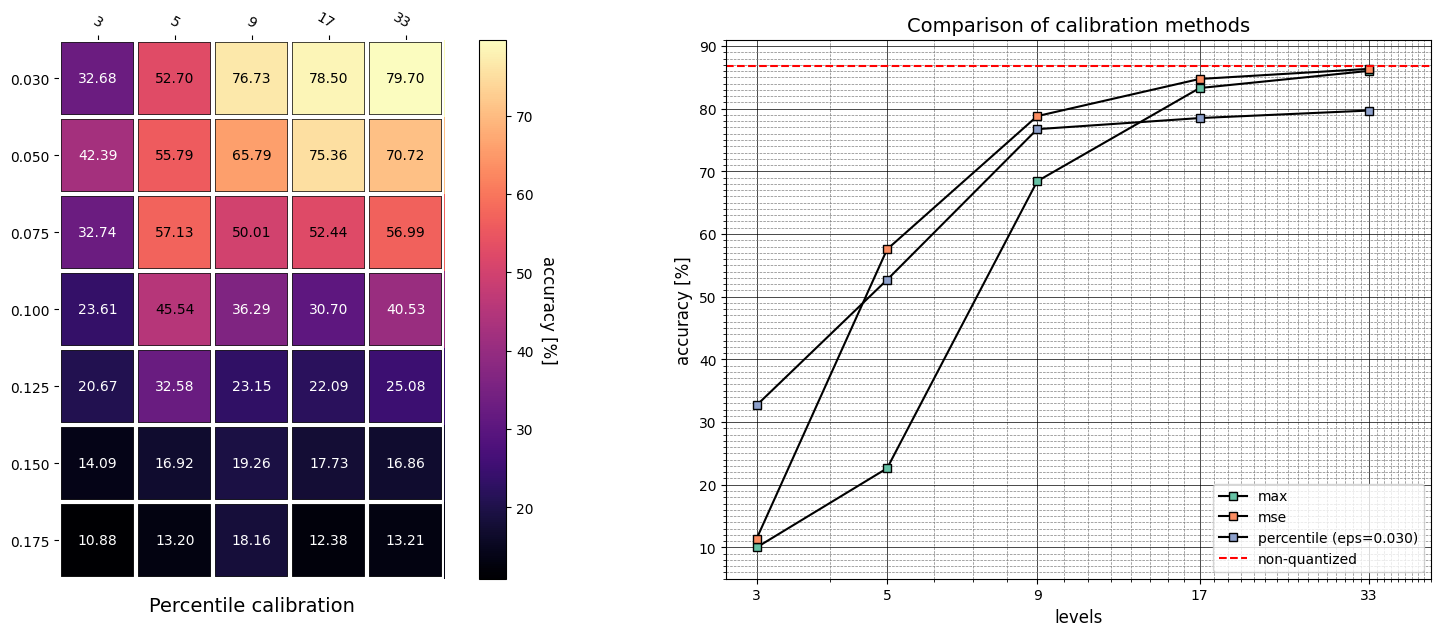

In [12]:
# =========================================================================================

fig, axs = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1, 1]})

xlabs = [f"{eps:.3f}" for eps in EPS]
ylabs = [str(levels) for levels in LEVELS]

im, cbar = heatmap( results["percentile"], row_labels = xlabs, col_labels = ylabs,
                   ax = axs[0], cmap = "magma", aspect = "equal", cbarlabel = "accuracy [%]", title = "Percentile calibration")
texts = annotate_heatmap(im, valfmt = "{x:.2f}")

# The second plot shows the comparison between the different calibration methods
data = np.array([ results["max"], results["mse"], results["percentile"][best_eps_index, :]])
x = LEVELS


colors = matplotlib.colormaps["Set2"].colors
axs[1].plot(x, data[0], label = "max", marker = "s", markerfacecolor = colors[0], color = "k")
axs[1].plot(x, data[1], label = "mse", marker = "s", markerfacecolor = colors[1], color = "k")
axs[1].plot(x, data[2], label = f"percentile (eps={best_eps:.3f})", marker = "s", markerfacecolor = colors[2], color = "k")

axs[1].set_xscale("log", base = 2)
axs[1].set_xticks(x)
axs[1].set_xticklabels([str(levels) for levels in x])
axs[1].set_xticks(np.arange(x[0], x[-1]+10, 1.0), minor = True)
axs[1].xaxis.set_minor_formatter(plt.NullFormatter())
axs[1].set_yticks(np.arange(np.min(data) -5, np.max(data) +5, 1.0), minor = True)
axs[1].axhline(y = results["non_quantized"], color = "red", linestyle = "--", label = "non-quantized", linewidth = 1.5)


axs[1].grid(which = "major", color = "k", linestyle = "-", linewidth = 0.5)
axs[1].grid(which = "minor", color = "grey", linestyle = "--", linewidth = 0.5)
axs[1].legend()
axs[1].set_xlabel("levels", fontdict = {"fontsize": 12})
axs[1].set_ylabel("accuracy [%]", fontdict = {"fontsize": 12})
axs[1].set_title("Comparison of calibration methods", fontdict = {"fontsize": 14})